In [342]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [350]:
session1 = pd.read_csv('/Users/yunaaraya/PycharmProjects/eeg-focus-tracker/src/data/sessions/session1.csv', index_col=0)
session2 = pd.read_csv('/Users/yunaaraya/PycharmProjects/eeg-focus-tracker/src/data/sessions/session2.csv', index_col=0)
session3 = pd.read_csv('/Users/yunaaraya/PycharmProjects/eeg-focus-tracker/src/data/sessions/session3.csv', index_col=0)
session4 = pd.read_csv('/Users/yunaaraya/PycharmProjects/eeg-focus-tracker/src/data/sessions/session4.csv', index_col=0)

In [351]:
len(session1), len(session2), len(session3), len(session4)

(282, 205, 242, 255)

In [352]:
session1['label'].value_counts(), session2['label'].value_counts(), session3['label'].value_counts(), session4['label'].value_counts()

(label
 0    150
 1    132
 Name: count, dtype: int64,
 label
 0    126
 1     79
 Name: count, dtype: int64,
 label
 0    122
 1    120
 Name: count, dtype: int64,
 label
 1    138
 0    117
 Name: count, dtype: int64)

In [353]:
session_df = pd.concat([session1, session2, session3, session4], ignore_index=True)

In [354]:
session_df.shape

(984, 26)

In [355]:
session_df.describe()

,TP9_theta,TP9_alpha,TP9_beta,TP9_theta_alpha,TP9_beta_alpha,TP9_engagement,AF7_theta,AF7_alpha,AF7_beta,AF7_theta_alpha,...,AF8_beta_alpha,AF8_engagement,TP10_theta,TP10_alpha,TP10_beta,TP10_theta_alpha,TP10_beta_alpha,TP10_engagement,alpha_asymmetry,label
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,...,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,0.000137,0.000108,0.000023,1.299558,0.230654,0.418307,0.000081,0.000060,0.000023,1.258914,...,0.389018,0.665051,0.000084,0.000074,0.000025,1.185820,0.349058,0.651470,-0.000093,0.476626
std,0.000046,0.000033,0.000006,0.501368,0.094673,0.154026,0.000026,0.000017,0.000003,0.411165,...,0.100523,0.140231,0.000023,0.000017,0.000004,0.406592,0.085530,0.135376,0.015422,0.499707
min,0.000046,0.000033,0.000012,0.395955,0.061760,0.143847,0.000030,0.000024,0.000014,0.385824,...,0.169351,0.341807,0.000020,0.000034,0.000014,0.336555,0.167845,0.319110,-0.083269,0.000000
25%,0.000104,0.000086,0.000018,0.948056,0.164362,0.312421,0.000063,0.000047,0.000021,0.973628,...,0.316135,0.565001,0.000068,0.000062,0.000023,0.892075,0.285583,0.554047,-0.002158,0.000000
50%,0.000129,0.000104,0.000021,1.194823,0.212962,0.390930,0.000077,0.000059,0.000023,1.204923,...,0.374824,0.650655,0.000081,0.000072,0.000025,1.114144,0.338405,0.634346,-0.000099,0.000000
75%,0.000162,0.000125,0.000026,1.540978,0.276099,0.494299,0.000093,0.000071,0.000025,1.492838,...,0.443443,0.751708,0.000098,0.000085,0.000028,1.384101,0.400652,0.731329,0.002628,1.000000
max,0.000389,0.000245,0.000053,3.825583,0.689179,1.313806,0.000203,0.000124,0.000034,3.166587,...,0.835284,1.358928,0.000182,0.000141,0.000038,3.195642,0.656478,1.279097,0.101079,1.000000


In [400]:
mean = session_df.groupby('label').mean()
mean

,TP9_theta,TP9_alpha,TP9_beta,TP9_theta_alpha,TP9_beta_alpha,TP9_engagement,AF7_theta,AF7_alpha,AF7_beta,AF7_theta_alpha,...,AF8_theta_alpha,AF8_beta_alpha,AF8_engagement,TP10_theta,TP10_alpha,TP10_beta,TP10_theta_alpha,TP10_beta_alpha,TP10_engagement,alpha_asymmetry
label,,,,,,,,,,,,,,,,,,,,,
0,0.000136,0.000108,0.000021,1.316729,0.220208,0.398377,0.000081,0.000062,0.000023,1.224978,...,1.436551,0.387313,0.664312,0.000084,0.000075,0.000026,1.174959,0.354177,0.666214,0.001263
1,0.000138,0.000108,0.000024,1.280702,0.242124,0.440191,0.000081,0.000058,0.000022,1.296178,...,1.446402,0.390891,0.665862,0.000084,0.000074,0.000025,1.197746,0.343437,0.635279,-0.001581


In [401]:
mean.diff()

,TP9_theta,TP9_alpha,TP9_beta,TP9_theta_alpha,TP9_beta_alpha,TP9_engagement,AF7_theta,AF7_alpha,AF7_beta,AF7_theta_alpha,...,AF8_theta_alpha,AF8_beta_alpha,AF8_engagement,TP10_theta,TP10_alpha,TP10_beta,TP10_theta_alpha,TP10_beta_alpha,TP10_engagement,alpha_asymmetry
label,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000002,5.331662e-07,0.000003,-0.036027,0.021916,0.041815,-4.914055e-07,-0.000004,-0.000001,0.071199,...,0.009851,0.003578,0.00155,5.479185e-07,-8.631816e-07,-0.000001,0.022787,-0.010741,-0.030935,-0.002844


In [398]:
std = session_df.std().drop('label')
std

TP9_theta           0.000046
TP9_alpha           0.000033
TP9_beta            0.000006
TP9_theta_alpha     0.501368
TP9_beta_alpha      0.094673
TP9_engagement      0.154026
AF7_theta           0.000026
AF7_alpha           0.000017
AF7_beta            0.000003
AF7_theta_alpha     0.411165
AF7_beta_alpha      0.158611
AF7_engagement      0.223804
AF8_theta           0.000023
AF8_alpha           0.000016
AF8_beta            0.000004
AF8_theta_alpha     0.463951
AF8_beta_alpha      0.100523
AF8_engagement      0.140231
TP10_theta          0.000023
TP10_alpha          0.000017
TP10_beta           0.000004
TP10_theta_alpha    0.406592
TP10_beta_alpha     0.085530
TP10_engagement     0.135376
alpha_asymmetry     0.015422
dtype: float64

In [402]:
d = mean.diff().loc[1] / std
d[abs(d) >=0.2]

TP9_beta           0.420601
TP9_beta_alpha     0.231486
TP9_engagement     0.271479
AF7_alpha         -0.242740
AF7_beta          -0.422366
TP10_beta         -0.313737
TP10_engagement   -0.228513
dtype: float64

<Axes: xlabel='label', ylabel='alpha_asymmetry'>

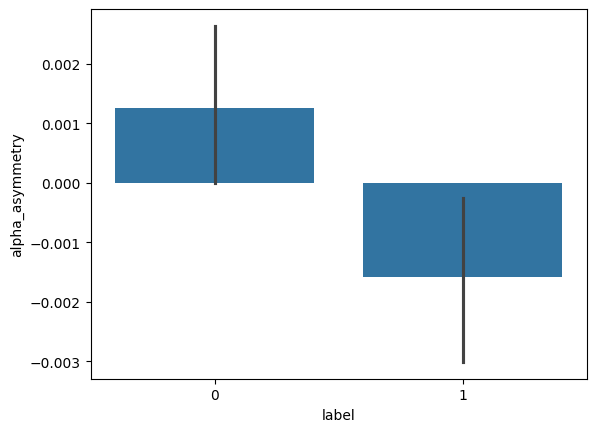

In [361]:
sns.barplot(session_df, x='label', y='alpha_asymmetry')

In [404]:
session7 = pd.read_csv('/Users/yunaaraya/PycharmProjects/eeg-focus-tracker/src/data/sessions/session7.csv')

In [405]:
session7.head()

,Unnamed: 0,TP9_theta,TP9_alpha,TP9_beta,TP9_theta_alpha,TP9_beta_alpha,TP9_engagement,AF7_theta,AF7_alpha,AF7_beta,...,AF8_beta_alpha,AF8_engagement,TP10_theta,TP10_alpha,TP10_beta,TP10_theta_alpha,TP10_beta_alpha,TP10_engagement,alpha_asymmetry,label
0,0,0.000099,0.000082,0.000011,1.339446,0.161360,0.278817,0.000062,0.000051,0.000019,...,0.406471,0.611999,0.000121,0.000063,0.000029,2.115457,0.446575,0.781966,0.000007,1
1,1,0.000126,0.000068,0.000010,2.042032,0.173020,0.243688,0.000075,0.000079,0.000019,...,0.329906,0.611082,0.000102,0.000059,0.000031,1.903506,0.494806,0.908071,0.000772,1
2,2,0.000153,0.000078,0.000013,2.181108,0.204014,0.277196,0.000073,0.000055,0.000022,...,0.686436,1.058219,0.000125,0.000061,0.000026,2.234918,0.399262,0.681501,0.000680,1
3,3,0.000125,0.000093,0.000014,1.488088,0.170116,0.280486,0.000067,0.000053,0.000024,...,0.851256,1.217250,0.000094,0.000068,0.000025,1.507673,0.354990,0.715738,0.001078,1
4,4,0.000072,0.000081,0.000018,0.984527,0.253350,0.494427,0.000065,0.000063,0.000026,...,0.450450,0.728905,0.000110,0.000076,0.000024,1.593370,0.301787,0.595748,0.000529,1


In [406]:
session7['label'].value_counts()

label
0    137
1     26
Name: count, dtype: int64

In [409]:
session7.groupby('label').agg(['mean', 'median']).T

label                            0          1
Unnamed: 0       mean    94.000000  12.500000
                 median  94.000000  12.500000
TP9_theta        mean     0.000117   0.000116
                 median   0.000115   0.000108
TP9_alpha        mean     0.000103   0.000091
                 median   0.000102   0.000084
TP9_beta         mean     0.000017   0.000015
                 median   0.000017   0.000016
TP9_theta_alpha  mean     1.313113   1.422367
                 median   1.296596   1.369270
TP9_beta_alpha   mean     0.210077   0.211997
                 median   0.195771   0.208465
TP9_engagement   mean     0.364604   0.363190
                 median   0.343278   0.340090
AF7_theta        mean     0.000070   0.000072
                 median   0.000067   0.000069
AF7_alpha        mean     0.000040   0.000055
                 median   0.000038   0.000055
AF7_beta         mean     0.000022   0.000023
                 median   0.000022   0.000023
AF7_theta_alpha  mean     1.752659   1.318453
                 median   1.749138   1.171946
AF7_beta_alpha   mean     0.612886   0.454147
                 median   0.594813   0.463070
AF7_engagement   mean     0.977075   0.819366
                 median   0.962104   0.801888
AF8_theta        mean     0.000075   0.000089
                 median   0.000074   0.000089
AF8_alpha        mean     0.000045   0.000051
                 median   0.000046   0.000050
AF8_beta         mean     0.000027   0.000027
                 median   0.000027   0.000027
AF8_theta_alpha  mean     1.444876   1.531944
                 median   1.389686   1.429510
AF8_beta_alpha   mean     0.602688   0.540693
                 median   0.582748   0.519564
AF8_engagement   mean     0.977856   0.849240
                 median   0.944435   0.834509
TP10_theta       mean     0.000081   0.000104
                 median   0.000079   0.000103
TP10_alpha       mean     0.000047   0.000056
                 median   0.000046   0.000057
TP10_beta        mean     0.000024   0.000025
                 median   0.000023   0.000025
TP10_theta_alpha mean     1.977602   2.118983
                 median   1.847938   2.013633
TP10_beta_alpha  mean     0.496532   0.460261
                 median   0.479328   0.443851
TP10_engagement  mean     0.901330   0.799938
                 median   0.878718   0.774150
alpha_asymmetry  mean     0.000076   0.000495
                 median   0.000072   0.000591

In [412]:
session8 = pd.read_csv('/Users/yunaaraya/PycharmProjects/eeg-focus-tracker/src/data/sessions/session8.csv')
session8['label'].value_counts()

label
0    151
1    151
Name: count, dtype: int64

In [417]:
session8.groupby('label').agg(['mean', 'median']).T

label                            0           1
Unnamed: 0       mean    75.000000  226.000000
                 median  75.000000  226.000000
TP9_theta        mean     0.000213    0.000224
                 median   0.000209    0.000207
TP9_alpha        mean     0.000130    0.000130
                 median   0.000127    0.000123
TP9_beta         mean     0.000018    0.000019
                 median   0.000017    0.000018
TP9_theta_alpha  mean     1.513031    1.611444
                 median   1.457847    1.504055
TP9_beta_alpha   mean     0.137391    0.146596
                 median   0.127220    0.140051
TP9_engagement   mean     0.205824    0.212882
                 median   0.199997    0.202923
AF7_theta        mean     0.000087    0.000091
                 median   0.000086    0.000089
AF7_alpha        mean     0.000056    0.000052
                 median   0.000056    0.000051
AF7_beta         mean     0.000024    0.000024
                 median   0.000024    0.000023
AF7_theta_alpha  mean     1.678696    1.873073
                 median   1.580467    1.790892
AF7_beta_alpha   mean     0.430070    0.454852
                 median   0.417203    0.447139
AF7_engagement   mean     0.753755    0.758271
                 median   0.735056    0.746452
AF8_theta        mean     0.000088    0.000097
                 median   0.000089    0.000097
AF8_alpha        mean     0.000067    0.000059
                 median   0.000066    0.000059
AF8_beta         mean     0.000027    0.000029
                 median   0.000027    0.000029
AF8_theta_alpha  mean     1.514759    1.859669
                 median   1.444263    1.865969
AF8_beta_alpha   mean     0.408179    0.487417
                 median   0.387744    0.475779
AF8_engagement   mean     0.718882    0.788664
                 median   0.705813    0.793700
TP10_theta       mean     0.000074    0.000082
                 median   0.000074    0.000081
TP10_alpha       mean     0.000052    0.000048
                 median   0.000051    0.000048
TP10_beta        mean     0.000023    0.000022
                 median   0.000023    0.000022
TP10_theta_alpha mean     1.571786    1.856553
                 median   1.487983    1.776712
TP10_beta_alpha  mean     0.480050    0.480229
                 median   0.458640    0.468741
TP10_engagement  mean     0.797453    0.742676
                 median   0.781425    0.722592
alpha_asymmetry  mean    -0.000829    0.000226
                 median  -0.000718    0.000181

In [420]:
session9 = pd.read_csv('/Users/yunaaraya/PycharmProjects/eeg-focus-tracker/src/data/sessions/session9.csv')
session10 = pd.read_csv('/Users/yunaaraya/PycharmProjects/eeg-focus-tracker/src/data/sessions/session10.csv')

In [435]:
session1.value_counts('label'), session2.value_counts('label'), session3.value_counts('label'), session4.value_counts('label'),

(label
 0    150
 1    132
 Name: count, dtype: int64,
 label
 0    126
 1     79
 Name: count, dtype: int64,
 label
 0    122
 1    120
 Name: count, dtype: int64,
 label
 1    138
 0    117
 Name: count, dtype: int64)

In [428]:
session5 = pd.read_csv('/Users/yunaaraya/PycharmProjects/eeg-focus-tracker/src/data/sessions/session5.csv')
session6 = pd.read_csv('/Users/yunaaraya/PycharmProjects/eeg-focus-tracker/src/data/sessions/session6.csv')

In [433]:
session5.value_counts('label'), session6.value_counts('label'), session7.value_counts('label'), session8.value_counts('label'),

(label
 0    150
 1    147
 Name: count, dtype: int64,
 label
 1    126
 0    125
 Name: count, dtype: int64,
 label
 0    137
 1     26
 Name: count, dtype: int64,
 label
 0    151
 1    151
 Name: count, dtype: int64)

In [434]:
session9.value_counts('label'), session10.value_counts('label')

(label
 0    130
 1     86
 Name: count, dtype: int64,
 label
 1    147
 0    144
 Name: count, dtype: int64)

In [443]:
session_df = pd.concat([session1, session2, session3, session4, session5, session6, session7, session8, session9, session10], ignore_index=True)

In [452]:
pd.set_option('display.max_rows', None)
summary = session_df.groupby('label').agg(['mean', 'median', 'std'])
summary.to_csv('summary.csv')


In [453]:
import os
import glob
import pandas as pd

def load_eeg_csv(directory_path):
    search_path = os.path.join(directory_path, '*.csv')
    all_files = glob.glob(search_path)
    if not all_files:
        raise FileNotFoundError('No .csv files found in {}'.format(directory_path))

    combined_df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

    return combined_df

In [455]:
df = load_eeg_csv('/Users/yunaaraya/PycharmProjects/eeg-focus-tracker/src/data/sessions')

In [458]:
df.shape

(3352, 27)

In [462]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3352 entries, 0 to 3351
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        3352 non-null   int64  
 1   TP9_theta         3352 non-null   float64
 2   TP9_alpha         3352 non-null   float64
 3   TP9_beta          3352 non-null   float64
 4   TP9_theta_alpha   3352 non-null   float64
 5   TP9_beta_alpha    3352 non-null   float64
 6   TP9_engagement    3352 non-null   float64
 7   AF7_theta         3352 non-null   float64
 8   AF7_alpha         3352 non-null   float64
 9   AF7_beta          3352 non-null   float64
 10  AF7_theta_alpha   3352 non-null   float64
 11  AF7_beta_alpha    3352 non-null   float64
 12  AF7_engagement    3352 non-null   float64
 13  AF8_theta         3352 non-null   float64
 14  AF8_alpha         3352 non-null   float64
 15  AF8_beta          3352 non-null   float64
 16  AF8_theta_alpha   3352 non-null   float64


In [463]:
df = df.drop('Unnamed: 0', axis=1)

In [464]:
df.head()

,TP9_theta,TP9_alpha,TP9_beta,TP9_theta_alpha,TP9_beta_alpha,TP9_engagement,AF7_theta,AF7_alpha,AF7_beta,AF7_theta_alpha,...,AF8_beta_alpha,AF8_engagement,TP10_theta,TP10_alpha,TP10_beta,TP10_theta_alpha,TP10_beta_alpha,TP10_engagement,alpha_asymmetry,label
0,0.000125,0.000080,0.000017,1.419968,0.197527,0.297919,0.000072,0.000048,0.000019,1.547501,...,0.598819,0.964823,0.000045,0.000055,0.000030,0.813482,0.561636,1.200511,-0.000902,1
1,0.000145,0.000109,0.000016,1.211643,0.139583,0.223148,0.000066,0.000054,0.000019,1.239141,...,0.453053,0.740518,0.000074,0.000054,0.000026,1.364117,0.499564,0.879360,-0.002947,1
2,0.000159,0.000084,0.000014,1.711081,0.154018,0.215280,0.000065,0.000060,0.000020,1.113022,...,0.467723,0.689984,0.000102,0.000064,0.000031,1.584353,0.498146,0.819046,-0.000144,1
3,0.000202,0.000075,0.000016,2.461167,0.199817,0.234950,0.000059,0.000101,0.000025,0.595255,...,0.555473,0.729212,0.000123,0.000049,0.000033,2.504969,0.686980,0.885462,0.009393,1
4,0.000289,0.000095,0.000015,2.772923,0.148790,0.164120,0.000065,0.000084,0.000028,0.782061,...,0.468140,0.694964,0.000084,0.000070,0.000030,1.188256,0.441643,0.823844,0.004649,1


In [466]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TP9_theta,3352.0,0.000163,0.000063,0.000046,0.000115,0.000152,0.000200,0.000468
TP9_alpha,3352.0,0.000119,0.000041,0.000033,0.000089,0.000111,0.000142,0.000332
TP9_beta,3352.0,0.000021,0.000006,0.000009,0.000017,0.000020,0.000025,0.000053
TP9_theta_alpha,3352.0,1.411083,0.506954,0.395955,1.050188,1.334031,1.682337,4.670328
TP9_beta_alpha,3352.0,0.207174,0.095167,0.042615,0.141318,0.188730,0.248893,1.098229
TP9_engagement,3352.0,0.356427,0.156392,0.072839,0.247752,0.328262,0.433745,1.478041
AF7_theta,3352.0,0.000083,0.000022,0.000030,0.000067,0.000081,0.000096,0.000203
AF7_alpha,3352.0,0.000064,0.000017,0.000024,0.000053,0.000063,0.000075,0.000153
AF7_beta,3352.0,0.000024,0.000004,0.000014,0.000022,0.000024,0.000026,0.000037
AF7_theta_alpha,3352.0,1.364241,0.462528,0.308800,1.030053,1.295577,1.616764,4.475743


In [469]:
df.value_counts('label')

label
0    1788
1    1564
Name: count, dtype: int64

In [473]:
summary = df.groupby('label').agg(['mean', 'std']).T

In [474]:
summary.to_csv('summary.csv')

In [475]:
df.to_csv('eeg_data.csv')

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats

def analyze_session(filepath):
    df = pd.read_csv(filepath, index_col=0)
    session_id = Path(filepath).stem  # e.g. "session1"

    results = {'session': session_id, 'n_samples': len(df)}

    for label in [0, 1]:
        sub = df[df['label'] == label]
        results[f'n_label_{label}'] = len(sub)

    # 1. CV (coefficient of variation) per feature — high CV = noisy session
    features = [c for c in df.columns if c != 'label']
    cvs = []
    for f in features:
        m = df[f].mean()
        s = df[f].std()
        cvs.append(s / abs(m) if m != 0 else np.nan)
    results['mean_cv'] = round(float(np.nanmean(cvs)), 3)

    # 2. Label separability — average Cohen's d across all features
    l0, l1 = df[df['label']==0], df[df['label']==1]
    if len(l0) > 5 and len(l1) > 5:
        ds = []
        for f in features:
            pooled = np.sqrt((l0[f].std()**2 + l1[f].std()**2) / 2)
            d = abs(l1[f].mean() - l0[f].mean()) / pooled if pooled > 0 else 0
            ds.append(d)
        results['mean_cohen_d'] = round(float(np.mean(ds)), 4)
    else:
        results['mean_cohen_d'] = np.nan

    # 3. Theta/alpha > 2.0 on average — possible drowsiness flag
    ta_cols = [c for c in df.columns if 'theta_alpha' in c]
    results['theta_alpha_mean'] = round(float(df[ta_cols].mean().mean()), 3)
    results['drowsy_flag'] = results['theta_alpha_mean'] > 2.0

    # 4. Outlier rate — samples where any feature > 3 std from session mean
    z = df[features].apply(lambda col: np.abs(stats.zscore(col)))
    outlier_rows = (z > 3).any(axis=1).sum()
    results['outlier_rate'] = round(outlier_rows / len(df), 3)

    # 5. Alpha asymmetry effect — p-value between labels
    if len(l0) > 5 and len(l1) > 5:
        _, p = stats.mannwhitneyu(
            l0['alpha_asymmetry'], l1['alpha_asymmetry'], alternative='two-sided'
        )
        results['asym_pval'] = round(float(p), 4)

    return results


In [11]:
# Run across all sessions
session_files = sorted(Path('/Users/yunaaraya/PycharmProjects/eeg-focus-tracker/src/data/sessions').glob('session*.csv'))
report = pd.DataFrame([analyze_session(f) for f in session_files])
print(report.to_string())

      session  n_samples  n_label_0  n_label_1  mean_cv  mean_cohen_d  theta_alpha_mean  drowsy_flag  outlier_rate  asym_pval
0    session1        282        150        132    0.342        0.2506             1.346        False         0.181     0.6286
1   session10        291        144        147    0.475        0.2148             1.302        False         0.144     0.0088
2   session11        255        135        120    1.162        0.3157             1.416        False         0.137     0.0007
3   session12        299        149        150    0.387        0.2849             1.403        False         0.134     0.0067
4   session13        294        152        142    0.403        0.3821             1.403        False         0.160     0.0000
5   session14        229         96        133    0.422        0.2921             1.661        False         0.122     0.0788
6   session15        251        142        109    0.527        0.3869             1.171        False         0.108    

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def leave_one_session_out(session_files):
    """
    Train on all sessions except one, test on the held-out session.
    Low AUC on a session = that session's patterns don't generalize.
    """
    dfs = {Path(f).stem: pd.read_csv(f, index_col=0) for f in session_files}
    features = [c for c in list(dfs.values())[0].columns if c != 'label']

    results = []
    for held_out, test_df in dfs.items():
        train_df = pd.concat(
            [df for name, df in dfs.items() if name != held_out]
        )

        X_train = train_df[features].values
        y_train = train_df['label'].values
        X_test  = test_df[features].values
        y_test  = test_df['label'].values

        scaler = StandardScaler().fit(X_train)
        rf = RandomForestClassifier(
            n_estimators=100, class_weight='balanced', random_state=42
        )
        rf.fit(scaler.transform(X_train), y_train)

        proba = rf.predict_proba(scaler.transform(X_test))[:, 1]
        auc = roc_auc_score(y_test, proba) if len(np.unique(y_test)) > 1 else np.nan

        results.append({'session': held_out, 'loso_auc': round(auc, 4)})
        print(f"{held_out}: AUC={auc:.4f}")

    return pd.DataFrame(results).sort_values('loso_auc')

In [12]:
loso_auc = leave_one_session_out(session_files)
loso_auc

session1: AUC=0.6605
session10: AUC=0.5037
session11: AUC=0.6460
session12: AUC=0.5400
session13: AUC=0.5672
session14: AUC=0.4305
session15: AUC=0.5589
session2: AUC=0.5464
session3: AUC=0.4569
session4: AUC=0.5189
session5: AUC=0.5275
session6: AUC=0.4843
session7: AUC=0.4913
session8: AUC=0.5343
session9: AUC=0.5288


,session,loso_auc
5,session14,0.4305
8,session3,0.4569
11,session6,0.4843
12,session7,0.4913
1,session10,0.5037
9,session4,0.5189
10,session5,0.5275
14,session9,0.5288
13,session8,0.5343
3,session12,0.5400
